# Evaluation on Modes of Climate Variability: \nPacific North-Atlantic Bias

# Libraries

In [1]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import ScalarFormatter
from typing import Dict, Tuple, AnyStr
from matplotlib import pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import cartopy.util as cutil
import cartopy.crs as ccrs
import seaborn as sns
from cdo import Cdo
import xarray as xr
import pandas as pd
import numpy as np
import cftime
import torch
import pywt 
import json
import glob
import cv2
import os

os.chdir('../..')

from wavesim.metrics import NormalizedRootMeanSquaredError, DataStructuralSimilarityIndex
from wavesim.utils import dataframe_to_markdown_table
from wavesim import WaveSim

%load_ext autoreload
%autoreload 2

# Load Observations

In [2]:
PRECT_obs = xr.open_dataset('data/reanalysis/prect.mon.mean.72x144.nc') # mm/day
SST_obs = xr.open_dataset('data/reanalysis/sst.mnmean.89x180.nc')
#T2M_obs = xr.open_dataset('data/reanalysis/air.2m.mon.mean.72x144.nc')#.sel(level=2.0)

In [3]:
# TODO: move to somewherelse
def ONI(sst_ds, lat, lon, climatology, reference_period):
    # Get climatology
    sst_clim = climatology
    
    # Extract SST data for reference period. Different ESMs use different names for SST
    ref_start, ref_end = reference_period
    var_name = 'tos' if 'tos' in sst_ds.data_vars else 'sst'
    sst = sst_ds[var_name].sel(time=slice(ref_start, ref_end))
    
    # calculate monthly anomaly
    sst_anom = sst.groupby('time.month') - sst_clim
    
    # extract SST data from the Nino 3.4 region
    sst_nino34 = sst_anom.sel(lat=lat, lon=lon)
    
    # calculate the mean values for the Nino 3.4 region
    nino34 = sst_nino34.mean(dim=["lat", "lon"])
    
    # calculate 3-month rolling mean of Nino 3.4 anomaly for the ONI
    oni = nino34.rolling(time=3, center=True).mean().dropna(dim='time')
    
    oni_bool = np.zeros_like(oni)

    for i in range(len(oni) - 4):
        if all(oni[i:i+5] >= 0.5):
            oni_bool[i:i+5] = 1
        elif all(oni[i:i+5] <= -0.5):
            oni_bool[i:i+5] = -1
            

    elnino_years = oni[oni_bool == 1].time.values
    lanina_years = oni[oni_bool == -1].time.values  

    return elnino_years, lanina_years, oni    

In [4]:
#sst_clim  = SST_obs.sst.sel(time=slice('1979-01', '2014-12')).groupby('time.month').mean(dim='time')

#elnino_years, lanina_years, oni = ONI(SST_obs, lat=slice(5, -5), lon=slice(190, 240), climatology=sst_clim, reference_period=('1979-01', '2014-12'))

# Load Earth System Model Data

In [5]:
ESM_bias_prect, ESM_bias_sst = {}, {}
#ESM = ['CESM2-FV2', 'FGOALS-g3', 'CMCC-CM2-HR4']
#ESM = ['CESM2', 'GFDL-ESM4', 'CMCC-CM2-HR4']
ESM = ['CESM2-FV2', 'CMCC-CM2-HR4', 'GFDL-ESM4']
#ESM = ['CESM2-WACCM', 'CMCC-CM2-HR4', 'GFDL-ESM4']
season = 'DJF'

seasons = {'DJF' : [12, 1, 2],
           'MAM' : [3, 4, 5],
           'JJA' : [6, 7, 8],
           'SON' : [9, 10, 11],
           'all' : np.arange(1, 13).tolist()}

pr_esm_base_path = f'data/CMIP6_monthly_data/remapped/pr/'
tos_esm_base_path = f'data/CMIP6_monthly_data/remapped/tos'

# 1. compute OBS SST climatology ('1979-01', '2014-12')
sst_obs_clim = SST_obs.sst.sel(time=slice('1979-01', '2014-12')).groupby('time.month').mean(dim='time')
prect_obs_clim = PRECT_obs.precip.sel(time=slice('1979-01', '2014-12')).groupby('time.month').mean('time')

elnino_years, lanina_years, oni = ONI(SST_obs, lat=slice(5, -5), lon=slice(190, 240), climatology=sst_obs_clim, reference_period=('1979-01', '2014-12'))

sst_obs_anom = SST_obs.groupby('time.month') - sst_obs_clim
SST_obs_NINO_values = sst_obs_anom.sel(time = elnino_years, method='nearest').where(sst_obs_anom.time.dt.month.isin(seasons[season])).mean('time').sst
SST_obs_NINA_values = sst_obs_anom.sel(time = lanina_years, method='nearest').where(sst_obs_anom.time.dt.month.isin(seasons[season])).mean('time').sst
ESM_bias_sst['OBS (SST)'] = SST_obs_NINO_values - SST_obs_NINA_values

prect_obs_anom = PRECT_obs.precip.groupby('time.month') - prect_obs_clim
PRECT_obs_NINO_values = prect_obs_anom.sel(time = elnino_years, method='nearest').where(prect_obs_anom.time.dt.month.isin(seasons[season])).mean('time')
PRECT_obs_NINA_values = prect_obs_anom.sel(time = lanina_years, method='nearest').where(prect_obs_anom.time.dt.month.isin(seasons[season])).mean('time')
ESM_bias_prect['OBS (GPCP)'] = PRECT_obs_NINO_values - PRECT_obs_NINA_values

# find the positive and negative ONI based on SST
for esm in ESM:
    print(f'Processing : {esm}')
    pr_esm_path = sorted(glob.glob(f'{pr_esm_base_path}/{esm}_pr_*.nc'))[0]
    pr_esm_df = xr.open_dataset(pr_esm_path)
    pr_clim = pr_esm_df.pr.sel(time=slice('1979-01', '2014-12')).groupby('time.month').mean('time')
    
    tos_esm_path = glob.glob(f'{tos_esm_base_path}/{esm}_tos_*.nc')[0]
    tos_esm_df = xr.open_dataset(tos_esm_path)
    tos_esm_clim = tos_esm_df.tos.groupby('time.month').mean(dim='time')
    
    # 2. for each ESM compute the positive and negative ONI index and extract years
    elnino_years, lanina_years, oni = ONI(tos_esm_df, lat=slice(5, -5), lon=slice(190, 240), climatology=tos_esm_clim, reference_period=('1979-01', '2014-12'))
    
    tos_anom = tos_esm_df.groupby('time.month') - tos_esm_clim
    SST_ESM_NINO_values = tos_anom.sel(time=elnino_years, method='nearest').where(tos_anom.time.dt.month.isin(seasons[season])).mean('time').tos
    SST_ESM_NINA_values = tos_anom.sel(time=lanina_years, method='nearest').where(tos_anom.time.dt.month.isin(seasons[season])).mean('time').tos
    ESM_bias_sst[esm] = SST_ESM_NINO_values - SST_ESM_NINA_values
    
    pr_anom = pr_esm_df.groupby('time.month') - pr_clim
    PRECT_ESM_NINO_values = pr_anom.sel(time=elnino_years, method='nearest').where(pr_anom.time.dt.month.isin(seasons[season])).mean('time').pr * 86400
    PRECT_ESM_NINA_values = pr_anom.sel(time=lanina_years, method='nearest').where(pr_anom.time.dt.month.isin(seasons[season])).mean('time').pr * 86400
    ESM_bias_prect[esm] = PRECT_ESM_NINO_values - PRECT_ESM_NINA_values

Processing : CESM2-FV2
Processing : CMCC-CM2-HR4
Processing : GFDL-ESM4


# Benchmark

In [6]:
wavesim_params = {'wavelet': 'db2',
                'mode': 'symmetric',
                'levels': 3,
                'operation': 'sum',
                'components_weight': {'alpha': 1.0, 'beta': 1.0, 'gamma': 1.0},
                'scales_weight': [0.333, 0.333, 0.333], # TODO : transform in a tensor (B, C, L+1)
                #'scales_weight': [0.25, 0.25, 0.25, 0.25], # TODO : transform in a tensor (B, C, L+1)
                'use_approx' : False,
                }

#nrsme_params = {'mode' : 'range'}
nrsme_params = {'p' : 1}

dssim_params = {'C1' : 1.0e-8, 
                'C2' : 1.0e-8, 
                'k' : 5, 
                'x_stddev' : 1.5, 
                'x_size' : 11, 
                'y_size' : 11, 
                'discretize' : True,
                'return_contrast' : False}

# Scores DataFrame

In [7]:
scores = pd.DataFrame(columns=['Earth System Model', 
                               'nrmse', 
                               'dssim', 
                               'wavesim',
                               'wavesim_components',
                               ]).astype({
                                        'Earth System Model': 'str', 
                                        'nrmse': np.float32,
                                        'dssim': np.float32,
                                        'wavesim': np.float32,
                                        'wavesim_components': 'str',
                                        })

## Run the Benchmark and get metrics scores

In [8]:
# Convert numpy arrays → Python lists, then to JSON string
def to_jsonable(d):
    return {k: v.tolist() for k, v in d.items()}

for esm in ESM_bias_prect.keys() - ['OBS (GPCP)']: 
    print(f'Processing {esm}...')
    
    nrmse_score = NormalizedRootMeanSquaredError(map1=ESM_bias_prect['OBS (GPCP)'], map2=ESM_bias_prect[esm], params=nrsme_params).compute()
    dssim_score = DataStructuralSimilarityIndex(map1=ESM_bias_prect['OBS (GPCP)'], map2=ESM_bias_prect[esm], params=dssim_params).compute()
    wavesim = WaveSim(map1=ESM_bias_prect['OBS (GPCP)'], map2=ESM_bias_prect[esm], params=wavesim_params) 
    
    wavesim_score = wavesim.compute()
    wavesim_components = {'magnitude': wavesim.magnitude_sim_score.numpy().ravel(),
                          'displacement': wavesim.displacement_sim_score.numpy().ravel(), 
                          'structure' : wavesim.structural_sim_score.numpy().ravel()
                          }
    
    # convert dict to json string
    wavesim_components_json = json.dumps(to_jsonable(wavesim_components))
    
    new_row = pd.DataFrame({'Earth System Model' : [esm],
                                'nrmse' : [nrmse_score],
                                'dssim' : [dssim_score],
                                'wavesim' : [wavesim_score],
                                'wavesim_components' : [wavesim_components_json]
                                })

    scores = pd.concat([scores, new_row], ignore_index=True)

Processing GFDL-ESM4...
Processing CMCC-CM2-HR4...
Processing CESM2-FV2...


## Save to CSV

In [9]:
scores.to_csv('examples/case_studies/nino_nina_composites_djf_scores.csv', index=False)

## Save to Markdown

In [10]:
dataframe_to_markdown_table(scores, 'examples/case_studies/nino_nina_composites_djf_scores.md')

Markdown table saved to examples/case_studies/nino_nina_composites_djf_scores.md


# El Niño - La Niña Spatial Composite Precipitation (DJF)

# Plot : Figure 4 of the Paper

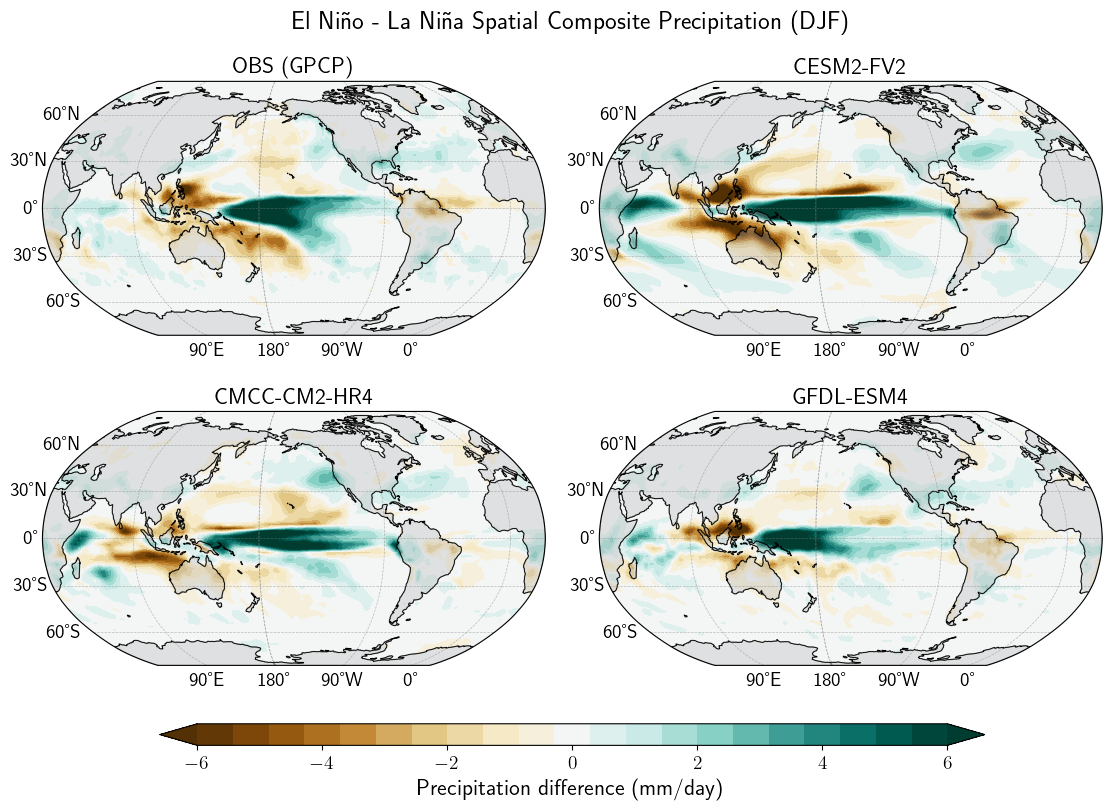

In [11]:
# Configure Matplotlib to use LaTeX
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'

lat = PRECT_obs.latitude.values
lon = PRECT_obs.longitude.values

vmin = -6
vmax = +6
abs_max = max(abs(vmin), abs(vmax))
levels = np.linspace(-abs_max, abs_max, 22)
ticks = np.linspace(-abs_max, abs_max, num=7)

# Create subplots with proper spacing for title and colorbar
fig, axs = plt.subplots(2, 2, figsize=(16.5, 8), 
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=205)})

for idx, ax in enumerate(axs.ravel()):
    key = list(ESM_bias_prect.keys())[idx]
    bias_, lon_, lat_ = cutil.add_cyclic(ESM_bias_prect[key], lon, lat)
        
    im = ax.contourf(lon_, lat_, bias_, levels=levels, cmap='BrBG', 
                     extend='both', transform=ccrs.PlateCarree())
    ax.set_title(f"{key}", fontsize=16)
    ax.set_facecolor("white")
    ax.coastlines(resolution='110m', linewidth=0.6, edgecolor="black", alpha=1.0)
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor='#B1B2B4', 
                   alpha=0.3, zorder=1)

    longitude_ticks = mticker.MultipleLocator(base=90.0)
    gl = ax.gridlines(draw_labels=True, xlocs=longitude_ticks, 
                      linestyle="--", linewidth=0.5, color="gray", alpha=0.5)
    
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}

# Add title with proper positioning
fig.suptitle(f'El Niño - La Niña Spatial Composite Precipitation ({season})', 
             fontsize=18, y=0.97)

# Adjust subplot positioning to make room for colorbar
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.15, top=0.88, 
                    wspace=-0.4, hspace=0.3)

# Add colorbar within figure bounds
cax = fig.add_axes([0.25, 0.05, 0.5, 0.027]) 
cbar = fig.colorbar(im, ax=axs.tolist(), cax=cax,
                    orientation='horizontal')
cbar.set_label(label='Precipitation difference (mm/day)', fontsize=16)
cbar.set_ticks(ticks)
cbar.ax.tick_params(labelsize=14)

# Save figure
#plt.show()
plt.savefig('figures/fig4.png', dpi=300, bbox_inches='tight')

# Plot : Figure 4 + Heatmaps

In [12]:
dec_precision = 2

In [13]:
path = '/Users/gabrieleaccarino/Workspace/wavesim/examples/case_studies/nino_nina_composites_djf_scores.csv'
scores = pd.read_csv(path)

scores['wavesim_components'] = scores['wavesim_components'].apply(
    lambda s: {k: np.array(v, dtype=np.float32) for k, v in json.loads(s).items()}
)

# Expand the nested data into a tidy (long) DataFrame
records = []
for _, row in scores.iterrows():
    esm = row["Earth System Model"]
    for component, values in row["wavesim_components"].items():
        for scale_idx, val in enumerate(values, start=1):
            records.append({
                "Earth System Model": esm,
                "component": component,
                "scale": f"Scale {scale_idx}",
                "value": val
            })
            
df_long = pd.DataFrame(records)

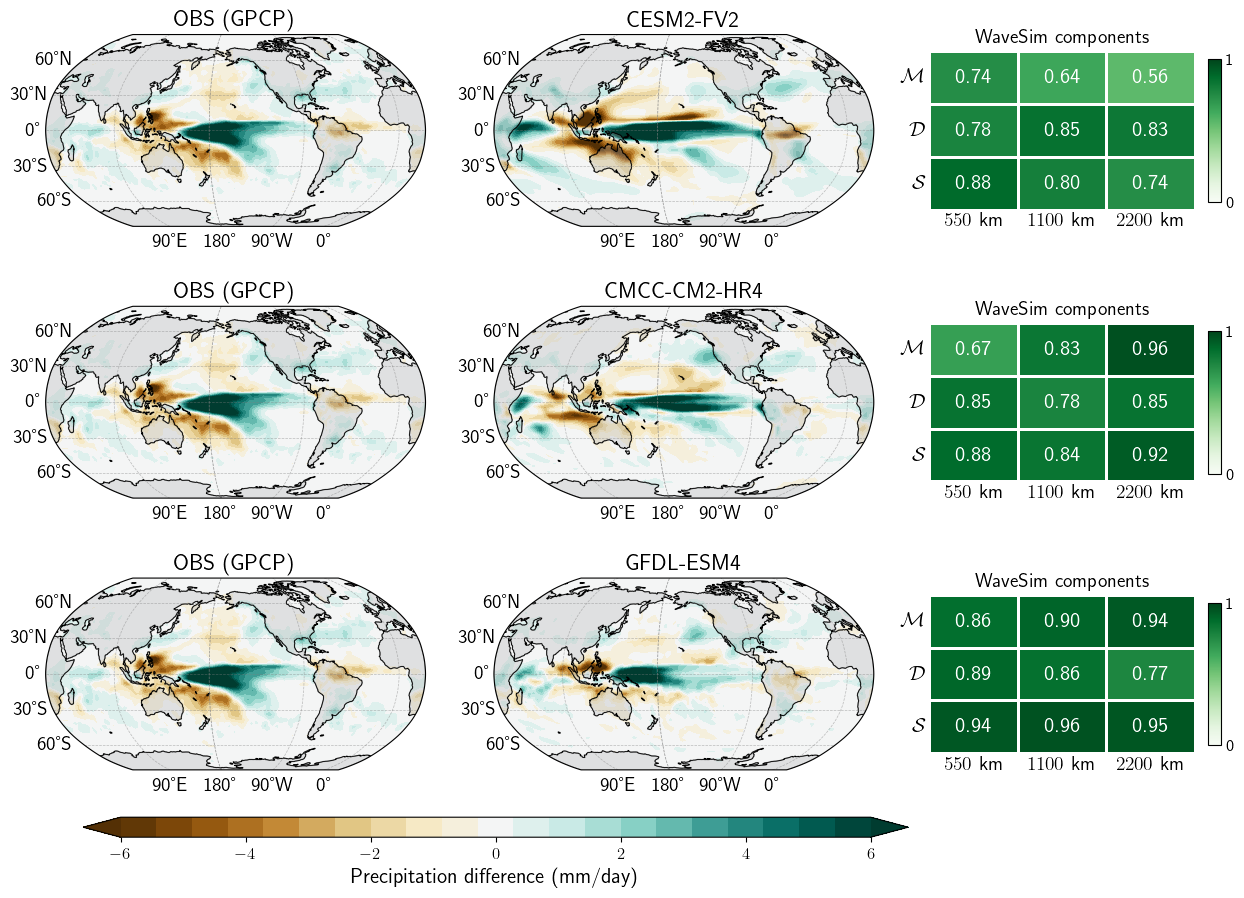

In [14]:
# --- Matplotlib LaTeX configuration ---
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'

obs_key = 'OBS (GPCP)'
esm_keys = [k for k in ESM_bias_prect.keys() if k != obs_key]  # only ESMs
nrows = len(esm_keys)

lat = PRECT_obs.latitude.values
lon = PRECT_obs.longitude.values

# colormap scaling
vmin, vmax = -6, +6
abs_max = max(abs(vmin), abs(vmax))
levels = np.linspace(-abs_max, abs_max, 22)
ticks = np.linspace(-abs_max, abs_max, 7)

# WaveSim label maps (adjust as needed)
component_map = {"magnitude": r"$\mathcal{M}$", "displacement": r"$\mathcal{D}$", "structure": r"$\mathcal{S}$"}
scale_map = {'Scale 1': r'$550$ km', 'Scale 2': r'$1100$ km', 'Scale 3': r'$2200$ km'}

# ------------ FIGURE LAYOUT -----------------

# Create subplots with proper spacing for title and colorbar
fig, axs = plt.subplots(nrows, 3, 
                        figsize=(15, 10), 
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=205)},
                        gridspec_kw={'width_ratios': [1, 1, 0.7]})

# Convert last column to standard Matplotlib axis
for i in range(nrows):
    axs[i, 2].remove()
    axs[i, 2] = fig.add_subplot(nrows, 3, i * 3 + 3)
    
# ------------ PLOT LOOP ----------------------
for i, esm in enumerate(esm_keys):

    
    # COL 0 = OBSERVATION (GPCP) – SAME IN ALL ROWS
    ax_obs = axs[i, 0]
    obs_data, lon_cyc, lat_cyc = cutil.add_cyclic(
        ESM_bias_prect[obs_key], lon, lat
    )

    im_obs = ax_obs.contourf(
        lon_cyc, lat_cyc, obs_data,
        levels=levels, cmap='BrBG',
        extend='both', transform=ccrs.PlateCarree()
    )
    ax_obs.set_title("OBS (GPCP)", fontsize=16)
    ax_obs.set_facecolor("white")
    ax_obs.coastlines(resolution='110m', linewidth=0.6, edgecolor="black", alpha=1.0)
    ax_obs.add_feature(cfeature.LAND, edgecolor="black", facecolor="#B1B2B4", alpha=0.3, zorder=1)

    longitude_ticks = mticker.MultipleLocator(base=90.0)
    gl = ax_obs.gridlines(draw_labels=True, xlocs=longitude_ticks, 
                      linestyle="--", linewidth=0.5, color="gray", alpha=0.5)
    
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}

    # COL 1 = ESM BIAS MAP
    ax_mod = axs[i, 1]

    esm_data, _, _ = cutil.add_cyclic(
        ESM_bias_prect[esm], lon, lat
    )

    im_mod = ax_mod.contourf(
        lon_cyc, lat_cyc, esm_data,
        levels=levels, cmap='BrBG',
        extend='both', transform=ccrs.PlateCarree()
    )
    ax_mod.set_title(esm, fontsize=16)
    ax_mod.set_facecolor("white")
    ax_mod.coastlines(resolution='110m', linewidth=0.6, edgecolor="black", alpha=1.0)
    ax_mod.add_feature(cfeature.LAND, edgecolor="black", facecolor="#B1B2B4", alpha=0.3, zorder=1)

    longitude_ticks = mticker.MultipleLocator(base=90.0)
    gl2 = ax_mod.gridlines(draw_labels=True, xlocs=longitude_ticks, 
                      linestyle="--", linewidth=0.5, color="gray", alpha=0.5)
    
    gl2.top_labels = False
    gl2.right_labels = False
    gl2.xlabel_style = {"size": 14}
    gl2.ylabel_style = {"size": 14}
    
    # COL 2 = WAVESIM HEATMAP (FOR THIS MODEL)
    ax_hm = axs[i, 2]
    
    pos = ax_hm.get_position() 
    
    new_width = pos.width #* 0.6
    new_height = pos.height * 0.7 
    new_x0 = pos.x0 + pos.width * -0.05
    new_y0 = pos.y0 + pos.height * 0.15
    
    ax_hm.set_position([new_x0, new_y0, new_width, new_height])

    plot_df = df_long[df_long["Earth System Model"] == esm].copy()

    # categorical formatting
    plot_df["component_label"] = pd.Categorical(
        plot_df["component"].map(component_map),
        categories=list(component_map.values()),
        ordered=True
    )
    plot_df["scale_label"] = pd.Categorical(
        plot_df["scale"].map(scale_map),
        categories=list(scale_map.values()),
        ordered=True
    )
    pivot = plot_df.pivot(index="component_label", columns="scale_label", values="value")

    hm = sns.heatmap(
        pivot,
        annot=True,
        fmt=f".{dec_precision}f",
        cmap="Greens", 
        vmin=0, 
        vmax=1,
        linewidths=1, 
        linecolor="white",
        annot_kws={"color": "white", "fontsize": 15},
        cbar=False,
        ax=ax_hm,
    )
    
    ax_hm.set_title("WaveSim components", fontsize=14, fontweight='bold')
    ax_hm.set_xlabel("")
    ax_hm.set_ylabel("")
    ax_hm.tick_params(axis='x', labelsize=14, length=0, pad=2)
    ax_hm.tick_params(axis='y', labelsize=15, length=0, pad=3)
    ax_hm.set_xticklabels(ax_hm.get_xticklabels(), rotation=0)
    ax_hm.set_yticklabels(ax_hm.get_yticklabels(), rotation=0)
    
    # Create a small colorbar axis next to the heatmap
    cax_hm = ax_hm.inset_axes([1.05, 0.05, 0.05, 0.9])  # [x0, y0, width, height] in relative coords
    cbar = fig.colorbar(ax_hm.collections[0], cax=cax_hm, orientation='vertical')
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["0", "1"])
    cbar.ax.tick_params(length=0, labelsize=12)
    cbar.ax.set_title("", pad=6)
    
# ------------ ADD COLORBAR -------------------

cax = fig.add_axes([0.15, 0.06, 0.55, 0.02])
cbar = fig.colorbar(im_mod, cax=cax, orientation='horizontal')
cbar.set_label('Precipitation difference (mm/day)', fontsize=15)
cbar.set_ticks(ticks)
cbar.ax.tick_params(labelsize=12)

# Add title with proper positioning
#fig.suptitle(f'El Niño - La Niña Spatial Composite Precipitation ({season})', 
#             fontsize=18, y=0.94)

#plt.subplots_adjust(hspace=1.5, wspace=0.01)

#plt.show()
plt.savefig("/Users/gabrieleaccarino/Workspace/wavesim/figures/fig4_heatmap.png", dpi=300, bbox_inches="tight")

# El Niño - La Niña Spatial Composite SST (*SEASON*)

In [ ]:
colors = ['RGB(118,39,230)', 'RGB(25,6,241)', 'RGB(49,71,226)', 'RGB(69,116,228)', 'RGB(71,149,247)', 'RGB(86,188,249)', 'RGB(135,198,238)', 'RGB(188,222,242)',
          'RGB(254,248,156)', 'RGB(248,216,82)', 'RGB(243,174,61)', 'RGB(238,129,49)', 'RGB(235,70,38)', 'RGB(214,46,31)', 'RGB(192,49,40)', 'RGB(244,180,179)']

NORMALIZED_COLORS = []
for color in colors:
    R, G, B = color.strip('RGB(').strip(')').split(',')
    #colors_normalized.append(f"RGB({int(R)/255},{int(G)/255},{int(B)/255})")
    # convert 
    NORMALIZED_COLORS.append((int(R)/255,int(G)/255,int(B)/255))

In [ ]:
# Configure Matplotlib to use LaTeX
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'

fig = plt.figure(figsize=(20, 8))

lat = SST_obs.lat.values
lon = SST_obs.lon.values

vmin = -3
vmax = 3
abs_max = max(abs(vmin), abs(vmax))
#levels = np.linspace(-abs_max, abs_max, 16)
#ticks = np.linspace(-abs_max, abs_max, num=7)
levels = np.linspace(vmin, vmax, 17)
ticks = np.linspace(vmin, vmax, num=7)

# other projections
#ccrs.PlateCarree(central_longitude=180), ccrs.Orthographic(central_longitude=180), ccrs.Robinson(central_longitude=180), ccrs.EckertIII(central_longitude=180), ccrs.EckertIV(central_longitude=180)

fig, axs = plt.subplots(2, 2, figsize=(12, 5), subplot_kw={'projection' : ccrs.Robinson(central_longitude=205)})  # Create GeoAxes with central longitude 180

cmap = ListedColormap(NORMALIZED_COLORS)
color_levels = [-3, -1.5, -0.5, 0.0, 0.5, 1.5, 3]
norm = BoundaryNorm(levels, ncolors=cmap.N) #, extend='both')

for idx, ax in enumerate(axs.ravel()):
    key = list(ESM_bias_sst.keys())[idx]

    bias_, lon_, lat_ = cutil.add_cyclic(ESM_bias_sst[key], lon, lat)
        
    #bias_plot = ax[0].pcolormesh(lon, lat, prect_obs_bias, transform=ccrs.PlateCarree(), cmap="BrBG", vmin=vmin, vmax=vmax) #RdBu_r
    #im = ax.contourf(lon_, lat_, bias_, levels=levels, cmap='RdYlBu_r', extend='both', transform=ccrs.PlateCarree())
    im = ax.contourf(lon_, lat_, bias_, levels=levels, cmap=cmap, norm=norm, extend='both', transform=ccrs.PlateCarree())
    #ax.set_title(f"{key} (Niño - Niña)", fontsize=16)
    ax.set_title(f"{key}", fontsize=14)
    ax.set_facecolor("white")  # Set white background for spatial plots
    ax.coastlines(resolution='110m', linewidth=0.6, edgecolor="black", alpha=1.0)
    #ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=0.5)
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor='#B1B2B4', alpha=0.3, zorder=1)

    # panel letter
    #axs[idx].annotate(f'( {panels[idx]} )', xy=(2, 5), xytext=(10, 22), bbox=dict(boxstyle="square,pad=0.4", fc="white", ec="black", linewidth=0))

    # cbar (one for each subplot)
    #cbar = plt.colorbar(bias_plot, ax=ax, orientation="horizontal", pad=0.1, aspect=40)
    #cbar.set_label(f"{key} (mm/day)", fontsize=14)
    #cbar.ax.tick_params(labelsize=10)  # Increase label size

    longitude_ticks = mticker.MultipleLocator(base=90.0) # long ticks every 90 deg
    gl = ax.gridlines(draw_labels=True, xlocs=longitude_ticks, linestyle="--", linewidth=0.5, color="gray", alpha=0.5)
    
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

fig.suptitle(f'El Niño - La Niña Spatial Composite SST ({season})', fontsize=16, y=1.05)

# single colorbar
cax = fig.add_axes([0.25, -0.05, 0.5, 0.03]) # [left, bottom, width, height]
cbar = fig.colorbar(im, ax=axs.tolist(), cax=cax,
                    #ticks = color_levels, ####
                    orientation='horizontal', pad=0.05,
                    aspect=60, shrink=0.9, label='°C', 
                    format=ScalarFormatter()) ####
#cbar.set_ticks(ticks)

#plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.9, wspace=-0.4, hspace=0.5)
#plt.tight_layout()
plt.show()